# A first EM algorithm

We observe ABO blood-type phenotypes in a sample. How can we estimate the frequencies of the A, B, and O alleles when phenotype does not always reveal genotype?

The A and B alleles are codominant, and O is recessive.

- Phenotype A can arise from genotype AA or AO.
- Phenotype B can arise from genotype BB or BO.
- Phenotype AB identifies genotype AB.
- Phenotype O identifies genotype OO.

The phenotype is observed. The genotype is latent. The three allele frequencies are unknown parameters.

If every genotype were known, we would estimate allele frequencies by counting allele copies. EM replaces the missing genotype counts with expected counts before performing the same calculation.

In [1]:
phenotype_count <- c(A = 39, B = 14, AB = 5, O = 42)
n_people <- sum(phenotype_count)

data.frame(
  phenotype = names(phenotype_count),
  count = unname(phenotype_count)
)

phenotype,count
<chr>,<dbl>
A,39
B,14
AB,5
O,42


## HWE supplies the genotype probabilities

Let $p_A$, $p_B$, and $p_O$ denote the allele frequencies. Under Hardy--Weinberg equilibrium (HWE),

| Phenotype | Possible genotypes | Probability |
| --- | --- | --- |
| A | AA or AO | $p_A^2+2p_Ap_O$ |
| B | BB or BO | $p_B^2+2p_Bp_O$ |
| AB | AB | $2p_Ap_B$ |
| O | OO | $p_O^2$ |

The A and B phenotype counts do not separate their two possible genotypes. HWE supplies the probabilities for that split.

## E step: split the ambiguous phenotypes

Among people with phenotype A, the current allele frequencies give

$$
P(AA\mid A)=\frac{p_A^2}{p_A^2+2p_Ap_O},
\qquad
P(AO\mid A)=\frac{2p_Ap_O}{p_A^2+2p_Ap_O}.
$$

Multiplying these probabilities by the observed A count gives expected counts for AA and AO. The B count is split between BB and BO in the same way. These are fractional genotype counts.

## M step: count alleles

Once every genotype has an observed or expected count, update the allele frequencies by counting copies.

$$
p_A \leftarrow \frac{2n_{AA}+n_{AO}+n_{AB}}{2n},
\qquad
p_B \leftarrow \frac{2n_{BB}+n_{BO}+n_{AB}}{2n},
$$

$$
p_O \leftarrow \frac{2n_{OO}+n_{AO}+n_{BO}}{2n}.
$$

The E step fills in expected genotype counts. The M step performs the allele counting we would use with complete data.

In [2]:
phenotype_probability <- function(frequency) {
  p_A <- frequency[["A"]]
  p_B <- frequency[["B"]]
  p_O <- frequency[["O"]]
  c(
    A = p_A^2 + 2 * p_A * p_O,
    B = p_B^2 + 2 * p_B * p_O,
    AB = 2 * p_A * p_B,
    O = p_O^2
  )
}

expected_genotype_count <- function(phenotype_count, frequency) {
  p_A <- frequency[["A"]]
  p_B <- frequency[["B"]]
  p_O <- frequency[["O"]]
  prob_A <- p_A^2 + 2 * p_A * p_O
  prob_B <- p_B^2 + 2 * p_B * p_O

  c(
    AA = unname(phenotype_count[["A"]] * p_A^2 / prob_A),
    AO = unname(phenotype_count[["A"]] * 2 * p_A * p_O / prob_A),
    BB = unname(phenotype_count[["B"]] * p_B^2 / prob_B),
    BO = unname(phenotype_count[["B"]] * 2 * p_B * p_O / prob_B),
    AB = unname(phenotype_count[["AB"]]),
    OO = unname(phenotype_count[["O"]])
  )
}

count_alleles <- function(genotype_count) {
  allele_count <- c(
    A = 2 * genotype_count[["AA"]] + genotype_count[["AO"]] +
      genotype_count[["AB"]],
    B = 2 * genotype_count[["BB"]] + genotype_count[["BO"]] +
      genotype_count[["AB"]],
    O = 2 * genotype_count[["OO"]] + genotype_count[["AO"]] +
      genotype_count[["BO"]]
  )
  allele_count / sum(allele_count)
}

observed_loglik <- function(phenotype_count, frequency) {
  probability <- phenotype_probability(frequency)
  sum(phenotype_count * log(probability[names(phenotype_count)]))
}

In [3]:
fit_abo_em <- function(phenotype_count,
                       start = c(A = 0.25, B = 0.15, O = 0.60),
                       tolerance = 1e-10, max_iter = 200) {
  frequency <- start
  history <- data.frame(
    iteration = 0L,
    p_A = frequency[["A"]],
    p_B = frequency[["B"]],
    p_O = frequency[["O"]],
    loglik = observed_loglik(phenotype_count, frequency)
  )

  for (iteration in seq_len(max_iter)) {
    genotype_count <- expected_genotype_count(phenotype_count, frequency)
    updated <- count_alleles(genotype_count)
    change <- max(abs(updated - frequency))
    frequency <- updated

    history <- rbind(
      history,
      data.frame(
        iteration = iteration,
        p_A = frequency[["A"]],
        p_B = frequency[["B"]],
        p_O = frequency[["O"]],
        loglik = observed_loglik(phenotype_count, frequency)
      )
    )

    if (change < tolerance) break
  }

  list(
    frequency = frequency,
    genotype_count = expected_genotype_count(phenotype_count, frequency),
    history = history
  )
}

In [4]:
fit <- fit_abo_em(phenotype_count)

data.frame(
  allele = names(fit$frequency),
  estimated_frequency = round(unname(fit$frequency), 4)
)

data.frame(
  genotype = names(fit$genotype_count),
  expected_count = round(unname(fit$genotype_count), 2)
)

to_frequency <- function(theta) {
  weight <- exp(c(
    A = unname(theta[1]),
    B = unname(theta[2]),
    O = 0
  ))
  weight / sum(weight)
}
negative_loglik <- function(theta) {
  -observed_loglik(phenotype_count, to_frequency(theta))
}
direct_fit <- optim(
  log(fit$frequency[c("A", "B")] / fit$frequency[["O"]]),
  negative_loglik,
  control = list(reltol = 1e-12)
)
direct_frequency <- to_frequency(direct_fit$par)

stopifnot(abs(sum(fit$frequency) - 1) < 1e-12)
stopifnot(all(diff(fit$history$loglik) >= -1e-10))
stopifnot(max(abs(fit$frequency - direct_frequency)) < 1e-5)

allele,estimated_frequency
<chr>,<dbl>
A,0.2517
B,0.1000
O,0.6483


genotype,expected_count
<chr>,<dbl>
AA,6.34
AO,32.66
BB,1.00
BO,13.00
AB,5.00
OO,42.00


## Why the repetition helps

The E step uses the current allele frequencies to split the A and B phenotypes. The M step uses those fractional genotype counts to recount the alleles. Each cycle increases, or leaves unchanged, the likelihood of the observed phenotype counts.

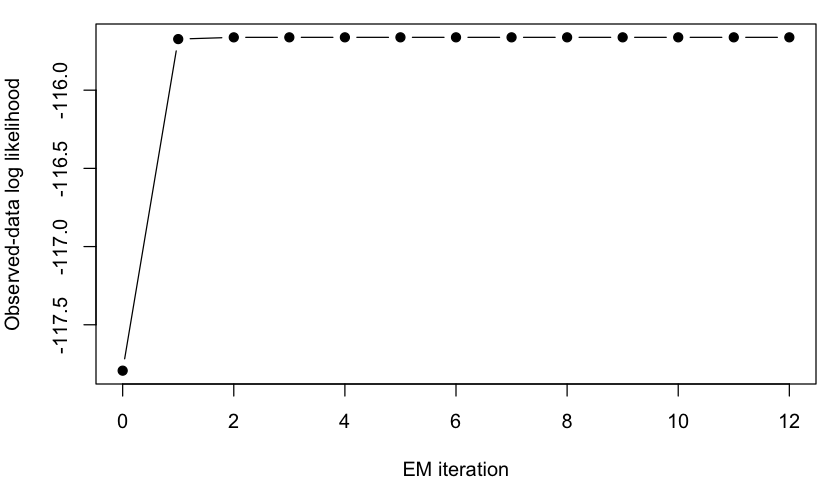

In [5]:
options(repr.plot.width = 7, repr.plot.height = 4)
par(mar = c(4, 4, 1, 1))
plot(
  fit$history$iteration,
  fit$history$loglik,
  type = "b",
  pch = 19,
  xlab = "EM iteration",
  ylab = "Observed-data log likelihood"
)

## What to remember

1. Phenotype A hides AA versus AO, and phenotype B hides BB versus BO.
2. The E step converts each ambiguous phenotype count into fractional genotype counts.
3. The M step counts allele copies and updates the three allele frequencies.

The [genotyping-error example](P8149_Lecture_2_MAF_MLE_EM.ipynb) uses the same idea. The latent object changes from an ABO genotype to a true genotype, but the E step still computes posterior counts and the M step still updates model parameters.

### Further reading

The phenotype counts are constructed to keep the arithmetic visible; no population inference is intended.

- Dempster, Laird, and Rubin (1977), *Maximum Likelihood from Incomplete Data via the EM Algorithm*.